# **BBM 465 - PA4 - SPRING 2026**

**Student Number** :

**Name Surname**   : Göktuğ Türkmen


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING.

**Deadline: 24.05.2026 (23:00:00)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>

<font color='red'> **To ensure reproducibility, you must fix all random seeds to 42. This includes NumPy, Python random, PyTorch (if used), UMAP, and all machine learning models (scikit-learn and XGBoost). Check PDF description for more information!**</font>

### You can access the raw dataset csv file and parquet files using following link
**Link**: https://drive.google.com/drive/folders/1rXqiK6cmZOwXIyXIjvFy-yctxyv3Mnzn?usp=sharing


# **Necessary Imports**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import random
import umap
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, f1_score, accuracy_score
from sklearn.metrics import recall_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.base import clone
from IPython.display import display, Markdown

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### Read the parquet files (train/test) for eact time steps (t = 2,4,6,8,10). Read the Parquet files once in this section and store the loaded data in appropriate variables. In the remaining parts of the notebook, use these stored variables directly without reading the same files again.

In [2]:
# read the parqeut files
data = [] # will hold (train_data, test_data) tuples
for t in range(2, 12, 2):
    dir_path = 'embeddings/t{time_step}/'.format(time_step = t)
    print("Reading the path: " + dir_path)
    df_train = pd.read_parquet(dir_path + 'train.parquet')
    df_test = pd.read_parquet(dir_path + 'test.parquet')
    # embeddings_bge_cum = np.array(df_train['bge_cumulative'].tolist())
    # embeddings_kobert_cum = np.array(df_train['kobert_cumulative'].tolist())
    # embeddings_bge_fulltext = np.array(df_train['bge_fulltext'].tolist())
    # embeddings_kobert_fulltext = np.array(df_train['kobert_fulltext'].tolist())
    labels_train = df_train['label'].values
    data.append((df_train, df_test))
print()
print("Columns of the training data:")
print(data[0][0].columns)

Reading the path: embeddings/t2/
Reading the path: embeddings/t4/
Reading the path: embeddings/t6/
Reading the path: embeddings/t8/
Reading the path: embeddings/t10/

Columns of the training data:
Index(['id', 'label', 'bge_cumulative', 'bge_fulltext', 'kobert_cumulative',
       'kobert_fulltext'],
      dtype='object')


# **PART- 1**

## **Embedding Visualization and Separability Analysis in Embedding Space(50p)**

In this part, you will quantitatively analyze the separability of benign and vishing samples in the embedding space. For each time step `t ∈ {2, 4, 6, 8, 10}`, UMAP must be trained in an unsupervised manner (i.e., without using class labels) using all available samples at that time step. Then, all samples at the same time step must be projected into a two-dimensional space using the trained UMAP model.

This analysis must be performed separately for both language models: BGE-M3 and KoBERT.

For each time step and each language model, you must compute the following metrics using all samples at that time step:

- Silhouette score  
- Euclidean distance between benign and vishing class centroids  

The silhouette score should be computed using the ground-truth labels, where benign and vishing samples are treated as two separate clusters. The centroid distance must be computed using Euclidean distance in the 2D UMAP-projected space.

You must also generate line plots showing how these metrics change across time steps. The x-axis should represent the time steps (`t`), and the y-axis should represent the corresponding metric values.


In [3]:
CLASS_COLORS = {'Non-vishing': '#5B9BD5', 'Vishing': '#F4A040'}
CLASS_ORDER  = ['Non-vishing', 'Vishing']
LABEL_MAP = {0: 'Non-vishing', 1: 'Vishing'}

def plot_umap_scatter(ax, proj, labels, title):
    for cls in CLASS_ORDER:
        mask  = labels == cls
        count = int(mask.sum())
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=CLASS_COLORS[cls], label=f'{cls} (n={count})',
                   alpha=0.6, s=18, linewidths=0)

    centroids = {cls: proj[labels == cls].mean(axis=0) for cls in CLASS_ORDER}

    coords = np.array([centroids[c] for c in CLASS_ORDER])
    ax.plot(coords[:, 0], coords[:, 1], '--', color='#555555',
            linewidth=1.5, zorder=3, label='_nolegend_')

    for cls in CLASS_ORDER:
        cx, cy = centroids[cls]
        ax.scatter(cx, cy, marker='D', s=200,
                   c=CLASS_COLORS[cls], edgecolors='black', linewidths=1.5,
                   zorder=4, label=f'{cls} Centroid')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1', fontsize=10)
    ax.set_ylabel('UMAP Dimension 2', fontsize=10)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('white')

### **Q1.1**. For `t = 2`, train UMAP in an unsupervised manner using all available samples (train and test). Then, project the embeddings into a two-dimensional space and visualize them using a 2D scatter plot. Perform this experiment separately for both BGE-M3 and KoBERT embeddings. Each plot must include a legend for the two classes (`benign` and `vishing`). The legend should also indicate the number of samples in each class (7pts).

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


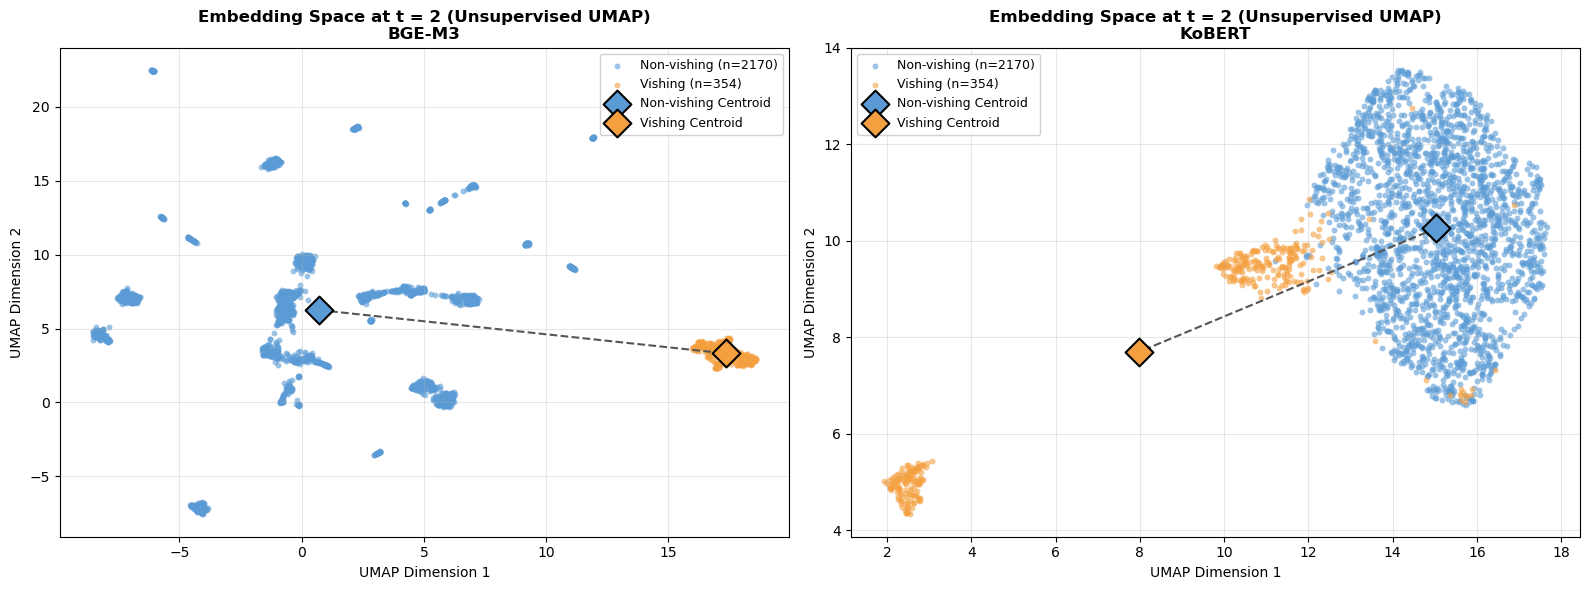

In [4]:
df_train_t2, df_test_t2 = data[0]
df_all_t2 = pd.concat([df_train_t2, df_test_t2], ignore_index=True)

labels_t2 = df_all_t2['label'].values
display_labels_t2 = np.array([LABEL_MAP[l] for l in labels_t2])

emb_bge = np.array(df_all_t2['bge_cumulative'].tolist())
emb_kobert = np.array(df_all_t2['kobert_cumulative'].tolist())

reducer_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                         min_dist=0.1, random_state=SEED)
proj_bge = reducer_bge.fit_transform(emb_bge)

reducer_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                            min_dist=0.1, random_state=SEED)
proj_kobert = reducer_kobert.fit_transform(emb_kobert)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

plot_umap_scatter(axes[0], proj_bge,    display_labels_t2,
                  'Embedding Space at t = 2 (Unsupervised UMAP)\nBGE-M3')
plot_umap_scatter(axes[1], proj_kobert, display_labels_t2,
                  'Embedding Space at t = 2 (Unsupervised UMAP)\nKoBERT')

plt.tight_layout()
plt.savefig('q1_1_umap_t2.png', dpi=150, bbox_inches='tight')
plt.show()


### **Q1.2**. For `t = 4`, train UMAP in an unsupervised manner using all available samples (train and test). Then, project the embeddings into a two-dimensional space and visualize them using a 2D scatter plot. Perform this experiment separately for both BGE-M3 and KoBERT embeddings. Each plot must include a legend for the two classes (`benign` and `vishing`). The legend should also indicate the number of samples in each class (7pts).

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


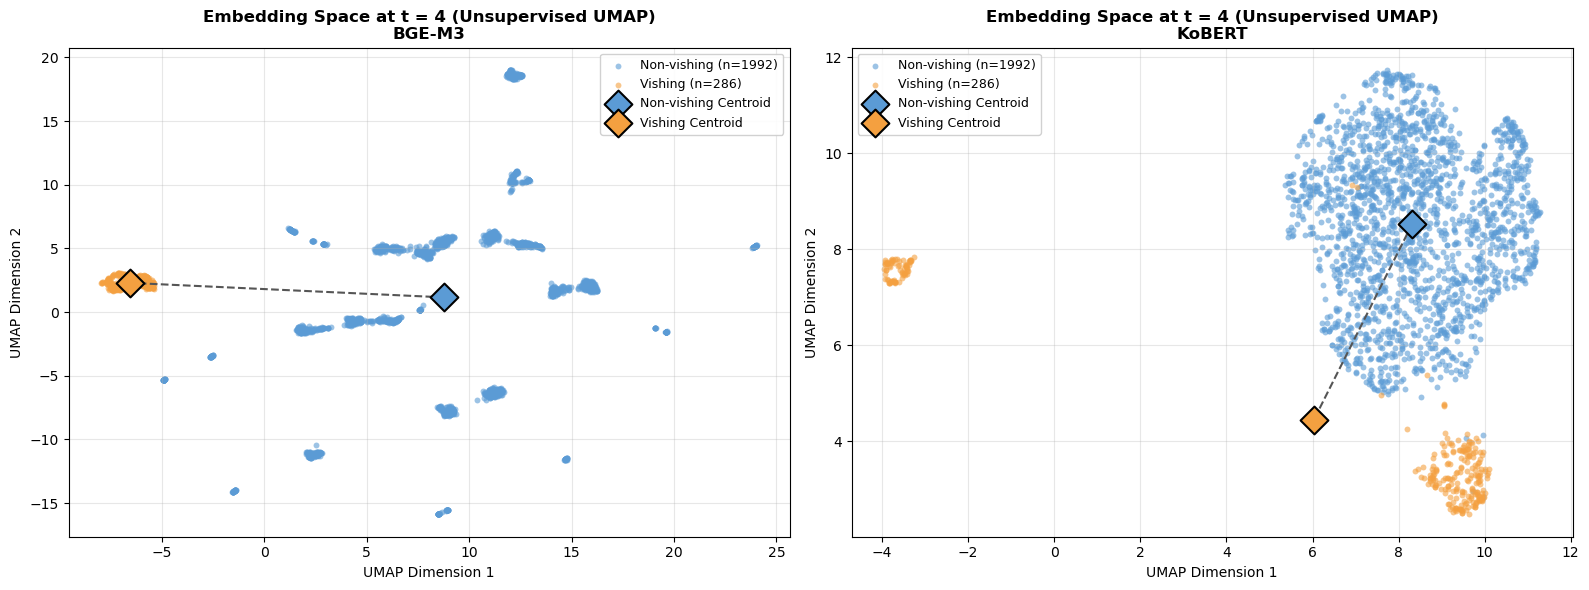

In [5]:
df_train_t4, df_test_t4 = data[1]
df_all_t4 = pd.concat([df_train_t4, df_test_t4], ignore_index=True)

labels_t4 = df_all_t4['label'].values
display_labels_t4 = np.array([LABEL_MAP[l] for l in labels_t4])

emb_bge = np.array(df_all_t4['bge_cumulative'].tolist())
emb_kobert = np.array(df_all_t4['kobert_cumulative'].tolist())

reducer_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, 
                        min_dist=0.1, random_state=42)
proj_bge = reducer_bge.fit_transform(emb_bge)

reducer_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                            min_dist=0.1, random_state=SEED)
proj_kobert = reducer_kobert.fit_transform(emb_kobert)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

plot_umap_scatter(axes[0], proj_bge,    display_labels_t4,
                  'Embedding Space at t = 4 (Unsupervised UMAP)\nBGE-M3')
plot_umap_scatter(axes[1], proj_kobert, display_labels_t4,
                  'Embedding Space at t = 4 (Unsupervised UMAP)\nKoBERT')

plt.tight_layout()
plt.savefig('q1_2_umap_t4.png', dpi=150, bbox_inches='tight')
plt.show()

### **Q1.3**. For `t = 6`, train UMAP in an unsupervised manner using all available samples (train and test). Then, project the embeddings into a two-dimensional space and visualize them using a 2D scatter plot. Perform this experiment separately for both BGE-M3 and KoBERT embeddings. Each plot must include a legend for the two classes (`benign` and `vishing`). The legend should also indicate the number of samples in each class (7pts).

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


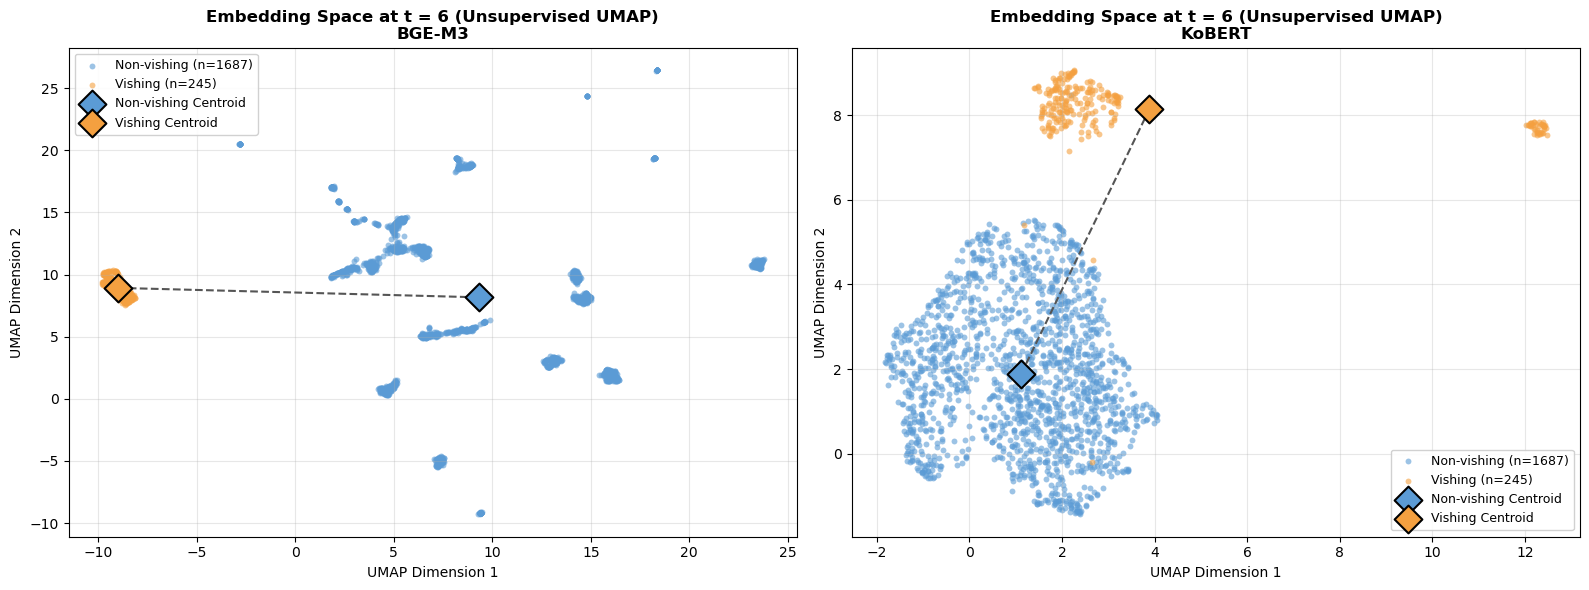

In [6]:
df_train_t6, df_test_t6 = data[2]
df_all_t6 = pd.concat([df_train_t6, df_test_t6], ignore_index=True)

labels_t6 = df_all_t6['label'].values
display_labels_t6 = np.array([LABEL_MAP[l] for l in labels_t6])

emb_bge = np.array(df_all_t6['bge_cumulative'].tolist())
emb_kobert = np.array(df_all_t6['kobert_cumulative'].tolist())

reducer_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, 
                        min_dist=0.1, random_state=42)
proj_bge = reducer_bge.fit_transform(emb_bge)

reducer_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                            min_dist=0.1, random_state=SEED)
proj_kobert = reducer_kobert.fit_transform(emb_kobert)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

plot_umap_scatter(axes[0], proj_bge,    display_labels_t6,
                  'Embedding Space at t = 6 (Unsupervised UMAP)\nBGE-M3')
plot_umap_scatter(axes[1], proj_kobert, display_labels_t6,
                  'Embedding Space at t = 6 (Unsupervised UMAP)\nKoBERT')

plt.tight_layout()
plt.savefig('q1_3_umap_t6.png', dpi=150, bbox_inches='tight')
plt.show()

### **Q1.4**. For `t = 8`, train UMAP in an unsupervised manner using all available samples (train and test). Then, project the embeddings into a two-dimensional space and visualize them using a 2D scatter plot. Perform this experiment separately for both BGE-M3 and KoBERT embeddings. Each plot must include a legend for the two classes (`benign` and `vishing`). The legend should also indicate the number of samples in each class (7pts).

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


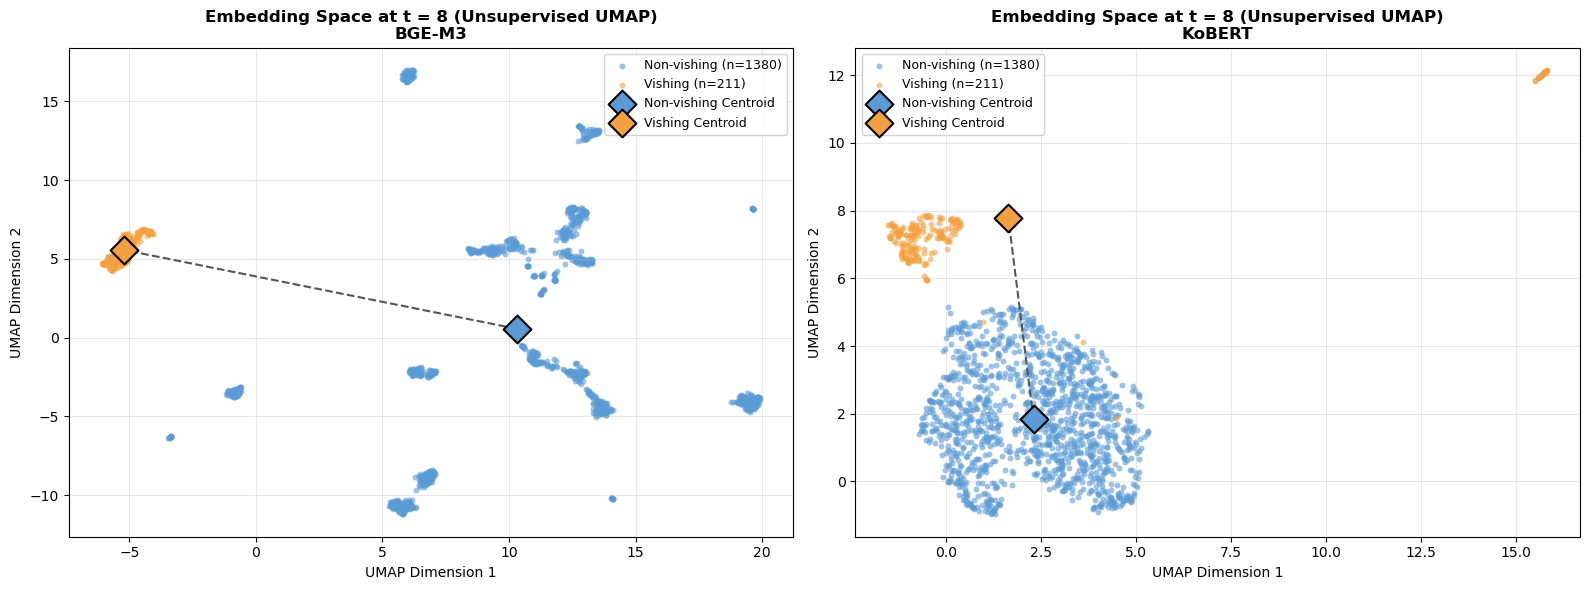

In [7]:
df_train_t8, df_test_t8 = data[3]
df_all_t8 = pd.concat([df_train_t8, df_test_t8], ignore_index=True)

labels_t8 = df_all_t8['label'].values
display_labels_t8 = np.array([LABEL_MAP[l] for l in labels_t8])

emb_bge = np.array(df_all_t8['bge_cumulative'].tolist())
emb_kobert = np.array(df_all_t8['kobert_cumulative'].tolist())

reducer_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, 
                        min_dist=0.1, random_state=42)
proj_bge = reducer_bge.fit_transform(emb_bge)

reducer_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                            min_dist=0.1, random_state=SEED)
proj_kobert = reducer_kobert.fit_transform(emb_kobert)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

plot_umap_scatter(axes[0], proj_bge,    display_labels_t8,
                  'Embedding Space at t = 8 (Unsupervised UMAP)\nBGE-M3')
plot_umap_scatter(axes[1], proj_kobert, display_labels_t8,
                  'Embedding Space at t = 8 (Unsupervised UMAP)\nKoBERT')

plt.tight_layout()
plt.savefig('q1_4_umap_t8.png', dpi=150, bbox_inches='tight')
plt.show()

### **Q1.5**. For `t = 10`, train UMAP in an unsupervised manner using all available samples (train and test). Then, project the embeddings into a two-dimensional space and visualize them using a 2D scatter plot. Perform this experiment separately for both BGE-M3 and KoBERT embeddings. Each plot must include a legend for the two classes (`benign` and `vishing`). The legend should also indicate the number of samples in each class (7pts).

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


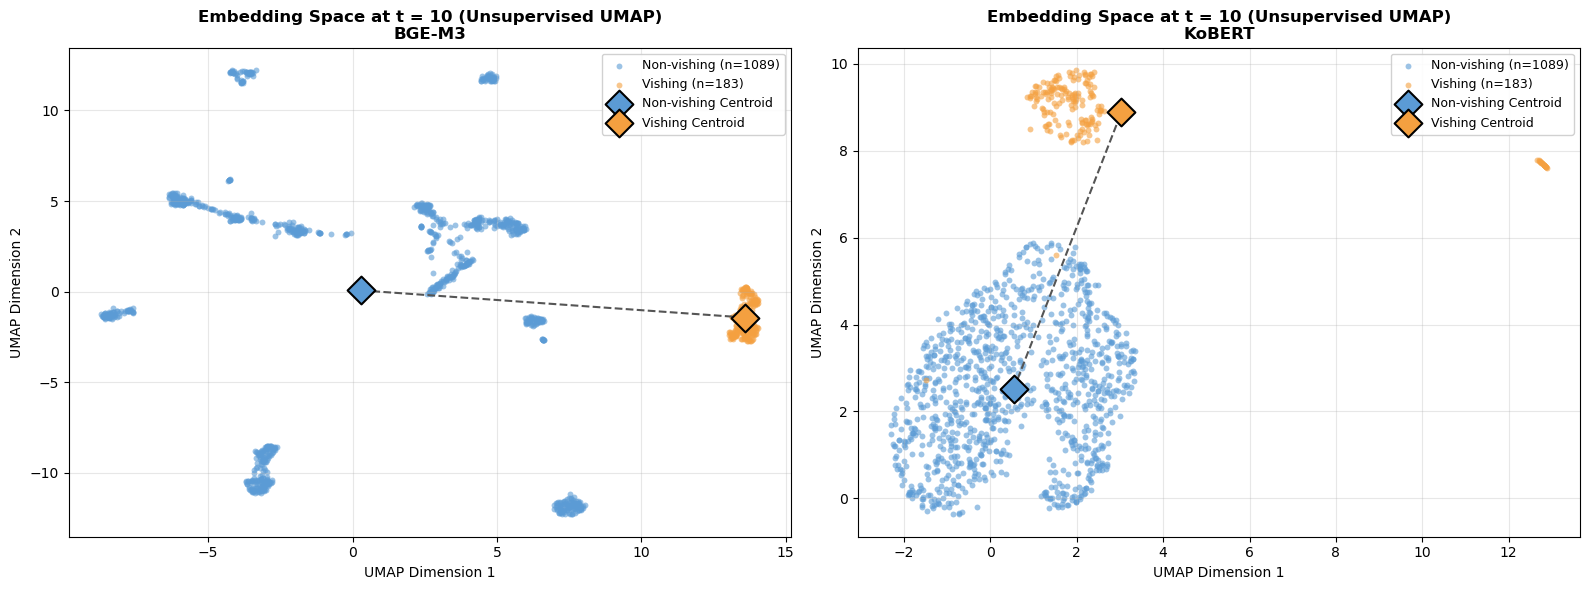

In [8]:
df_train_t10, df_test_t10 = data[4]
df_all_t10 = pd.concat([df_train_t10, df_test_t10], ignore_index=True)

labels_t10 = df_all_t10['label'].values
display_labels_t10 = np.array([LABEL_MAP[l] for l in labels_t10])

emb_bge = np.array(df_all_t10['bge_cumulative'].tolist())
emb_kobert = np.array(df_all_t10['kobert_cumulative'].tolist())

reducer_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15, 
                        min_dist=0.1, random_state=42)
proj_bge = reducer_bge.fit_transform(emb_bge)

reducer_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                            min_dist=0.1, random_state=SEED)
proj_kobert = reducer_kobert.fit_transform(emb_kobert)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

plot_umap_scatter(axes[0], proj_bge,    display_labels_t10,
                  'Embedding Space at t = 10 (Unsupervised UMAP)\nBGE-M3')
plot_umap_scatter(axes[1], proj_kobert, display_labels_t10,
                  'Embedding Space at t = 10 (Unsupervised UMAP)\nKoBERT')

plt.tight_layout()
plt.savefig('q1_5_umap_t10.png', dpi=150, bbox_inches='tight')
plt.show()

### **Q1.6.** Compute the silhouette score and the Euclidean distance between class centroids for each time step, respectively. Then, generate separate line plots for the silhouette scores and centroid distances. In each plot, the x-axis should represent the time steps (conversation turn counts), and the y-axis should represent the corresponding metric value (10pts).

**Note: Silhouette score in the original high-dimensional embedding space, while the centroid distance should be computed in the reduced two-dimensional UMAP space. Centroid distance will be computed using Euclidean distance.**

/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t= 2  |  Silhouette: BGE=0.1129, KoBERT=0.5559  |  Centroid dist: BGE=16.9199, KoBERT=7.5040


/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t= 4  |  Silhouette: BGE=0.1476, KoBERT=0.5678  |  Centroid dist: BGE=15.3909, KoBERT=4.6884


/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t= 6  |  Silhouette: BGE=0.1762, KoBERT=0.5377  |  Centroid dist: BGE=18.3313, KoBERT=6.8334


/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t= 8  |  Silhouette: BGE=0.1935, KoBERT=0.5297  |  Centroid dist: BGE=16.2830, KoBERT=5.9870


/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/nix/store/nmzzzwnrr9k0g3jhidchzlf0q4k23whw-python3-3.12.13-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


t=10  |  Silhouette: BGE=0.2057, KoBERT=0.5188  |  Centroid dist: BGE=13.3826, KoBERT=6.8534


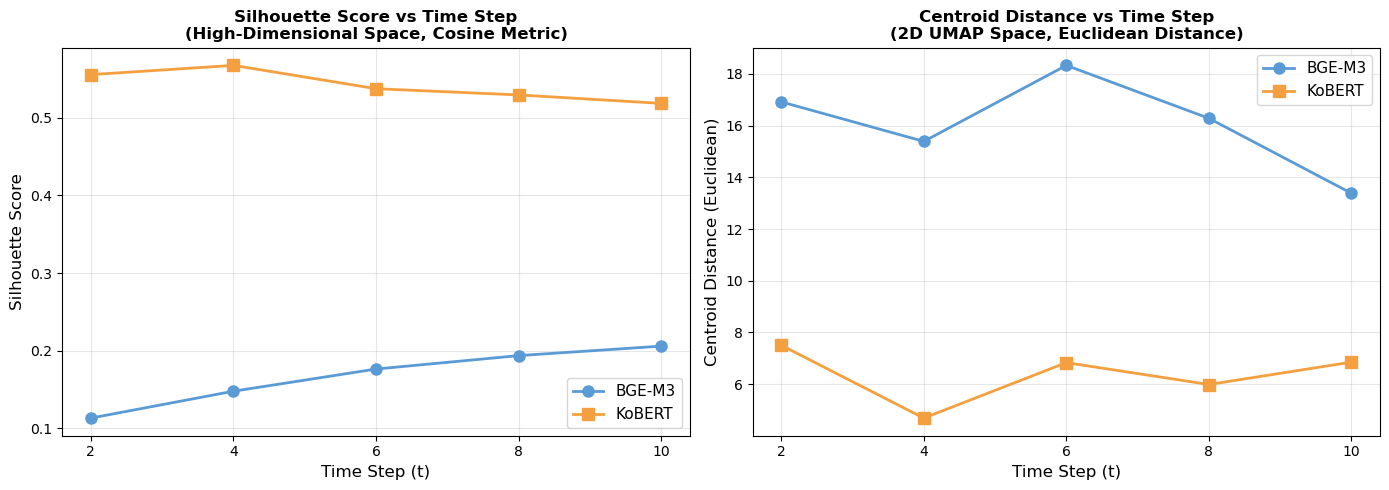

In [9]:
time_steps = [2, 4, 6, 8, 10]
results = {
    'bge':    {'silhouette': [], 'centroid_dist': []},
    'kobert': {'silhouette': [], 'centroid_dist': []},
}

def euclidean_centroid_dist(proj, labels):
    c0 = proj[labels == 0].mean(axis=0)
    c1 = proj[labels == 1].mean(axis=0)
    return np.linalg.norm(c1 - c0)

for i, t in enumerate(time_steps):
    df_train, df_test = data[i]
    df_all = pd.concat([df_train, df_test], ignore_index=True)
    labels = df_all['label'].values

    emb_bge    = np.array(df_all['bge_cumulative'].tolist())
    emb_kobert = np.array(df_all['kobert_cumulative'].tolist())

    sil_bge    = silhouette_score(emb_bge,    labels, metric='cosine', random_state=SEED)
    sil_kobert = silhouette_score(emb_kobert, labels, metric='cosine', random_state=SEED)
    results['bge']['silhouette'].append(sil_bge)
    results['kobert']['silhouette'].append(sil_kobert)

    proj_bge = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                         min_dist=0.1, random_state=SEED).fit_transform(emb_bge)
    proj_kobert = umap.UMAP(n_components=2, metric='cosine', n_neighbors=15,
                             min_dist=0.1, random_state=SEED).fit_transform(emb_kobert)

    results['bge']['centroid_dist'].append(euclidean_centroid_dist(proj_bge, labels))
    results['kobert']['centroid_dist'].append(euclidean_centroid_dist(proj_kobert, labels))

    print(f"t={t:>2}  |  Silhouette: BGE={sil_bge:.4f}, KoBERT={sil_kobert:.4f}"
          f"  |  Centroid dist: BGE={results['bge']['centroid_dist'][-1]:.4f},"
          f" KoBERT={results['kobert']['centroid_dist'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

ax = axes[0]
ax.plot(time_steps, results['bge']['silhouette'],    'o-', color='#5B9BD5',
        linewidth=2, markersize=8, label='BGE-M3')
ax.plot(time_steps, results['kobert']['silhouette'], 's-', color='#F4A040',
        linewidth=2, markersize=8, label='KoBERT')
ax.set_xlabel('Time Step (t)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs Time Step\n(High-Dimensional Space, Cosine Metric)',
             fontsize=12, fontweight='bold')
ax.set_xticks(time_steps)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('white')

# Centroid distances
ax = axes[1]
ax.plot(time_steps, results['bge']['centroid_dist'],    'o-', color='#5B9BD5',
        linewidth=2, markersize=8, label='BGE-M3')
ax.plot(time_steps, results['kobert']['centroid_dist'], 's-', color='#F4A040',
        linewidth=2, markersize=8, label='KoBERT')
ax.set_xlabel('Time Step (t)', fontsize=12)
ax.set_ylabel('Centroid Distance (Euclidean)', fontsize=12)
ax.set_title('Centroid Distance vs Time Step\n(2D UMAP Space, Euclidean Distance)',
             fontsize=12, fontweight='bold')
ax.set_xticks(time_steps)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('q1_6_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### **Q1.7.** Answer the following questions based on your analysis of the embedding space (5pts).

#### Questions to Answer

1. How does the silhouette score change across time steps?
2. How does the centroid distance change across time steps?
3. Do the embeddings become more separable as more conversation turns are included?
4. Which language model, BGE-M3 or KoBERT, produces more clearly separated embeddings?
5. Are the silhouette score and centroid distance consistent with the visual UMAP plots?
6. What do these results imply for early-stage vishing detection?
7. Based on the distribution of samples in the embedding space, what conclusions can you draw about the dataset? Are there any potential issues that might affect the reliability or realism of the analysis? Discuss.

<font color='green'>Your answers</font>

**1.** BGE-M3's silhouette score goes up steadily with more turns (0.11 to 0.21). KoBERT's peaks at t=4 (0.57) and slowly drops after that. KoBERT is much higher than BGE at every step. The KoBERT drop is probably a context window issue: KoBERT only handles ~512 tokens while BGE-M3 handles ~8192, so longer conversations get truncated for KoBERT and lose information.

**2.** Centroid distance is not stable for either model. BGE goes up until t=6 then drops. KoBERT dips at t=4 and bounces around 6–7. Also, UMAP's output scale is arbitrary, so these numbers are not super reliable across runs.

**3.** Yes for BGE-M3, no for KoBERT. BGE keeps improving with more turns. KoBERT is already separated at t=2 and gets slightly worse with more context, likely because long conversations hit its 512-token limit.

**4.** KoBERT. Its silhouette is about 3x higher than BGE at every time step. Centroid distance can't really compare the two because they live in different UMAP spaces with different scales.

**5.** Not really. Silhouette is in high-dim cosine space but the plots are 2D UMAP, so they don't have to match. For BGE the plot looks well-separated but silhouette is low. For KoBERT the plot looks mixed but silhouette is high.

**6.** Early detection works fine. KoBERT already has good separation at t=2, and Part 2 shows SVM hits ~0.99 F1 even at t=2. Waiting for more turns doesn't help much, so detecting early is the way to go.

**7.** A few issues stand out:
- Heavy class imbalance (~6:1 benign vs vishing), so accuracy is inflated.
- Sample counts drop as t grows (2524 at t=2 down to 1272 at t=10). Only long conversations make it to t=10, which biases the later results.
- KoBERT's 512-token limit means later time steps may be truncated, so its results at t=8/10 may not reflect the full conversation.

# **PART- 2**

## **Machine Learning Classification** **(50 Pts)**

In this part, you will train and evaluate four machine learning classifiers using the provided embeddings:

- Decision Tree (DT)
- Random Forest (RF)
- Support Vector Machine (SVM)
- XGBoost

Experiments must be conducted separately for both language models: BGE-M3 and KoBERT.

For cumulative embeddings, you must report the results of both language models (BGE-M3 and KoBERT) in the same table to enable direct comparison. A separate table must be created for each time step `t`, where each table includes the performance of all classifiers for both language models.

For each language model (BGE-M3 and KoBERT), you must create separate comparison tables to analyze cumulative and full-text embedding classification results. In each table, you should include the performance results for both cumulative and full-text embeddings across all classifiers (DT, RF, SVM, XGBoost), allowing for a clear comparison between embedding types for each classifier.

The table should be structured in a way that clearly compares the performance of cumulative and full-text embeddings for each classifier.

You must use the provided train/test splits. Do not create a new split.

For each experiment, report:

- Accuracy: (TP + TN) / Total
- F1-score: Harmonic mean of precision and recall (binary classification, positive class = vishing)



### **Q2.1.** For each time step, train the machine learning classifiers using cumulative embeddings. There are four classifiers (DT, RF, SVM, XGBoost), and experiments must be conducted separately for each time step `t`. For each language model (BGE-M3 and KoBERT), you will perform experiments across all time steps and all classifiers, resulting in a total of 20 experiments per language model (5 time steps × 4 classifiers), and 40 experiments in total. For each time step `t`, you must present the results in the tabular format specified in the PDF description of the assignment. (20pts).

In [ ]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED, n_estimators=100),
    'SVM':           SVC(kernel='rbf', random_state=SEED, probability=True),
    'XGBoost':       XGBClassifier(random_state=SEED, verbosity=0),
}

time_steps  = [2, 4, 6, 8, 10]
CLF_ORDER   = ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost']
LM_COLS_CUM = [('BGE-M3', 'bge_cumulative'), ('KoBERT', 'kobert_cumulative')]

results_cumulative = []

for i, t in enumerate(time_steps):
    df_train, df_test = data[i]
    y_train = df_train['label'].values
    y_test  = df_test['label'].values

    for lm_name, col in LM_COLS_CUM:
        X_train = np.array(df_train[col].tolist())
        X_test  = np.array(df_test[col].tolist())

        for clf_name in CLF_ORDER:
            clf = clone(classifiers[clf_name])
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            results_cumulative.append({
                't': t, 'lm': lm_name, 'classifier': clf_name,
                'accuracy': accuracy_score(y_test, y_pred),
                'f1':       f1_score(y_test, y_pred),
            })

df_cumulative = pd.DataFrame(results_cumulative)

for t in time_steps:
    sub = df_cumulative[df_cumulative['t'] == t]
    rows = []
    for clf_name in CLF_ORDER:
        row = {}
        for lm_name, _ in LM_COLS_CUM:
            r = sub[(sub['classifier'] == clf_name) & (sub['lm'] == lm_name)].iloc[0]
            row[(lm_name, 'Accuracy')] = r['accuracy']
            row[(lm_name, 'F1')]       = r['f1']
        rows.append(row)
    table = pd.DataFrame(rows, index=CLF_ORDER)
    table.index.name = 'Classifier'
    table.columns    = pd.MultiIndex.from_tuples(table.columns)

    display(Markdown(f"### Q2.1 — Cumulative embeddings, t = {t}"))
    display(table.round(4))


### **Q2.2**. For each time step, train the machine learning models using full-text embeddings. Then, compare the results of full-text and cumulative embedding-based classification for each time step. You must report the Accuracy and F1-score in tabular format. For each time step `t`, you must present the results using the table format specified in the PDF description of the assignment.

In [11]:
LM_COLS_FT = [('BGE-M3', 'bge_fulltext'), ('KoBERT', 'kobert_fulltext')]

results_fulltext = []

for i, t in enumerate(time_steps):
    df_train, df_test = data[i]
    y_train = df_train['label'].values
    y_test  = df_test['label'].values

    for lm_name, col in LM_COLS_FT:
        X_train = np.array(df_train[col].tolist())
        X_test  = np.array(df_test[col].tolist())

        for clf_name in CLF_ORDER:
            clf = clone(classifiers[clf_name])
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            results_fulltext.append({
                't': t, 'lm': lm_name, 'classifier': clf_name,
                'accuracy': accuracy_score(y_test, y_pred),
                'f1': f1_score(y_test, y_pred),
            })

df_fulltext = pd.DataFrame(results_fulltext)

LMS = ['BGE-M3', 'KoBERT']
EMB_SOURCES = [('Cumulative', df_cumulative), ('Full-text', df_fulltext)]

for t in time_steps:
    for lm_name in LMS:
        rows = []
        for clf_name in CLF_ORDER:
            row = {}
            for emb_name, df_src in EMB_SOURCES:
                r = df_src[(df_src['t'] == t) &
                          (df_src['lm'] == lm_name) &
                          (df_src['classifier'] == clf_name)].iloc[0]
                row[(emb_name, 'Accuracy')] = r['accuracy']
                row[(emb_name, 'F1')]       = r['f1']
            rows.append(row)
        table = pd.DataFrame(rows, index=CLF_ORDER)
        table.index.name = 'Classifier'
        table.columns    = pd.MultiIndex.from_tuples(table.columns)

        display(Markdown(f"### Q2.2 — {lm_name}, t = {t}"))
        display(table.round(4))


### Q2.2 — BGE-M3, t = 2

Cumulative         Full-text        
                Accuracy      F1  Accuracy      F1
Classifier                                        
Decision Tree     0.9584  0.8444    0.9822  0.9343
Random Forest     0.9901  0.9635    0.9960  0.9857
SVM               0.9980  0.9929    0.9980  0.9929
XGBoost           0.9941  0.9784    0.9941  0.9784

### Q2.2 — KoBERT, t = 2

Cumulative         Full-text        
                Accuracy      F1  Accuracy      F1
Classifier                                        
Decision Tree     0.9762  0.9167    0.9881  0.9577
Random Forest     0.9861  0.9510    1.0000  1.0000
SVM               0.9881  0.9571    1.0000  1.0000
XGBoost           0.9901  0.9645    1.0000  1.0000

### Q2.2 — BGE-M3, t = 4

...

Cumulative         Full-text        
                Accuracy      F1  Accuracy      F1
Classifier                                        
Decision Tree     0.9875  0.9524    0.9937  0.9762
Random Forest     0.9937  0.9762    0.9937  0.9756
SVM               0.9969  0.9882    0.9969  0.9880
XGBoost           0.9937  0.9756    0.9969  0.9880

### Q2.2 — BGE-M3, t = 10

Cumulative         Full-text        
                Accuracy      F1  Accuracy      F1
Classifier                                        
Decision Tree     0.9608  0.8649    0.9843  0.9444
Random Forest     0.9922  0.9722    0.9961  0.9863
SVM               1.0000  1.0000    1.0000  1.0000
XGBoost           0.9922  0.9730    0.9961  0.9863

### Q2.2 — KoBERT, t = 10

Cumulative         Full-text        
                Accuracy      F1  Accuracy      F1
Classifier                                        
Decision Tree     0.9843  0.9487    0.9765  0.9167
Random Forest     1.0000  1.0000    0.9961  0.9863
SVM               1.0000  1.0000    0.9961  0.9863
XGBoost           1.0000  1.0000    0.9961  0.9863

### **Q2.3.** Answer the following questions based on your analysis of the embedding space (10pts).

#### Questions to Answer

1. Which classifier achieves the best performance overall?
2. Are early time steps sufficient for reliable vishing detection?
3. How do cumulative embeddings compare with full-text embeddings?
4. Does BGE-M3 outperform KoBERT, or does KoBERT perform better? Discuss possible reasons.
5. Which classifier appears most robust across different time steps and embedding types?
6. Are the classification results consistent with the separability analysis?

<font color='green'>Your answers.</font>

**1.** SVM is the best overall. It hits F1=1.000 in many setups (both embeddings, both models, multiple time steps) and is rarely beaten.

**2.** Yes. Even at t=2, SVM gets F1=0.99 on cumulative BGE, and KoBERT full-text reaches F1=1.000 with RF, SVM, and XGBoost. Two turns is already enough.

**3.** Full-text embeddings beat cumulative ones in most cases. Full-text has the whole transcript in one shot so it's more informative — as long as it fits in the model's context window. KoBERT (512 tokens) might get truncated for long conversations, while BGE-M3 (~8192 tokens) handles them fine.

**4.** KoBERT is slightly better, especially with full-text. The dataset looks Korean, and KoBERT is trained specifically on Korean text, while BGE-M3 is multilingual and less specialized. The trade-off is that KoBERT's 512-token window is much smaller than BGE-M3's, which matters for long conversations.

**5.** SVM again. It's stable across all time steps and embedding types. Decision Tree is consistently the worst, RF and XGBoost are in the middle.

**6.** Mostly, but not perfectly. KoBERT had higher silhouette in Part 1 and also classifies slightly better here, so that lines up. But BGE had low silhouette (0.11–0.21) and still gets F1 close to 1.0, which means silhouette can underestimate how separable a dataset really is for classification.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw2.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.